# Import & Settings

In [14]:
import os
import pathlib
import time
import collections
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from util_funcs.metric import score as cmi_score
import random
from torch.utils.data import DataLoader
from miniai.init import *
from torch.optim.lr_scheduler import OneCycleLR
from functools import partial
from miniai.learner import *
from miniai.activations import ActivationStats
from torcheval.metrics import MulticlassAccuracy,MeanSquaredError
from miniai.sgd import BatchSchedCB,RecorderCB,EpochSchedCB
from torch.optim.lr_scheduler import ExponentialLR
from torcheval.metrics import MulticlassAccuracy
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW


In [40]:

tof_data_mean = torch.Tensor([39.7010])
tof_data_std = torch.Tensor([63.7176])
from util_funcs.cmi_utils import encoder_with_pooling,preprocess_tof_tens

In [37]:
SEED = 2025
BASE_DIR = pathlib.Path("data")
OUT_DIR = pathlib.Path(".")
print("output dir:", OUT_DIR)

# data
ID_COL = "sequence_id"
SEQ_COL = "sequence_counter"

TARGET = "gesture"
MAX_LENGTH = 55

# model
NUM_CLASSES = 18
HIDDEN_SIZE = 256
N_LAYERS=1
BIDIRECTIONAL = True
DROP = 0.15
ADDED_PADDING = 4
# trainig
BATCH_SIZE = 200
EPOCHS = 70
LR = 1e-3
LR_MIN = 1e-5
DEVICE = torch.device("cuda")

output dir: .


In [17]:
FEATURES = ['acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5']

# Load

In [18]:
path_data = BASE_DIR / "train.csv"
header = pd.read_csv(path_data, nrows=0)
columns = header.columns
columns = [x for x in columns]

columns

['row_id',
 'sequence_type',
 'sequence_id',
 'sequence_counter',
 'subject',
 'orientation',
 'behavior',
 'phase',
 'gesture',
 'acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5',
 'tof_1_v0',
 'tof_1_v1',
 'tof_1_v2',
 'tof_1_v3',
 'tof_1_v4',
 'tof_1_v5',
 'tof_1_v6',
 'tof_1_v7',
 'tof_1_v8',
 'tof_1_v9',
 'tof_1_v10',
 'tof_1_v11',
 'tof_1_v12',
 'tof_1_v13',
 'tof_1_v14',
 'tof_1_v15',
 'tof_1_v16',
 'tof_1_v17',
 'tof_1_v18',
 'tof_1_v19',
 'tof_1_v20',
 'tof_1_v21',
 'tof_1_v22',
 'tof_1_v23',
 'tof_1_v24',
 'tof_1_v25',
 'tof_1_v26',
 'tof_1_v27',
 'tof_1_v28',
 'tof_1_v29',
 'tof_1_v30',
 'tof_1_v31',
 'tof_1_v32',
 'tof_1_v33',
 'tof_1_v34',
 'tof_1_v35',
 'tof_1_v36',
 'tof_1_v37',
 'tof_1_v38',
 'tof_1_v39',
 'tof_1_v40',
 'tof_1_v41',
 'tof_1_v42',
 'tof_1_v43',
 'tof_1_v44',
 'tof_1_v45',
 'tof_1_v46',
 'tof_1_v47',
 'tof_1_v48',
 'tof_1_v49',
 'tof_1_v50',
 'tof_1_v51',
 'tof_1_v52',
 'tof_1_v53',
 'tof

In [19]:
data = pd.read_csv(path_data, usecols=columns)

data.shape

(574945, 341)

In [159]:
#convert the target column to codes
cat = pd.Categorical(data[TARGET], ordered=True).dtype
data[TARGET] = pd.Categorical(data[TARGET], ordered=True)
data[TARGET] = data[TARGET].cat.codes

In [20]:
tof_cols =[x for x in header.columns if x.startswith("tof")]
data[tof_cols].head(5)

,tof_1_v0,tof_1_v1,tof_1_v2,tof_1_v3,tof_1_v4,tof_1_v5,tof_1_v6,tof_1_v7,tof_1_v8,tof_1_v9,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,131.0,134.0,132.0,135.0,98.0,74.0,64.0,60.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,130.0,138.0,131.0,135.0,101.0,76.0,66.0,61.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,137.0,136.0,147.0,109.0,90.0,81.0,74.0,74.0,-1.0,164.0,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,143.0,147.0,170.0,127.0,109.0,98.0,95.0,95.0,-1.0,177.0,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,178.0,191.0,183.0,157.0,146.0,139.0,143.0,148.0,-1.0,-1.0,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


### Reshaping the tof data into a single image



In [21]:
single_row = data[tof_cols].iloc[0].values

In [24]:
ADDED_PADDING = 4
import torch
from torch.nn import functional
import torch.nn as nn

reshape_tof_row = lambda tof_row: torch.reshape(functional.pad(tof_row,(0,ADDED_PADDING)),(18,18))


In [94]:
#need to go back to this cell after adding the tof features to the list of features

class CMIData(Dataset):
    def __init__(self, data, max_length=None):
        super().__init__()
        self.d_data = dict(list(data.groupby(ID_COL)))
        self.features = FEATURES
        self.target = TARGET
        self.max_length = max_length
        self.keys = list(self.d_data)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, index):
        
        df = self.d_data[self.keys[index]]
        if self.max_length is not None:
            df = df.iloc[-self.max_length :]
        return (
            torch.tensor(df[self.features].values.astype(np.float32)),
            torch.tensor(df[self.target].values[-1].astype(np.int64)),
        )

In [140]:
entire_ds = CMIData(data=data,max_length=55)

In [177]:
def preprocess_tof_data(data,tof_cols):

    data_tof = torch.from_numpy(data[tof_cols].values)
    reshaped_data_tof = [reshape_tof_row(tof_row) for tof_row in data_tof]
    reshaped_tof_rows = torch.stack(reshaped_data_tof)
    stacked_tensor = torch.nan_to_num(reshaped_tof_rows.float(),nan=0.0)

    return stacked_tensor

def transform_tof_data(encoder_model,tof_tensor):
    encoder_with_pooling.to("cuda")
    with torch.no_grad():

        output_features = encoder_model(preprocess_tof_tens(tof_tensor).to("cuda"))

    flattened = output_features.view(output_features.size(0), -1).to("cpu")

    return flattened

In [47]:
def reload_mod(mod):from importlib import reload;reload(mod)
from util_funcs import cmi_utils
reload_mod(cmi_utils)

In [356]:
#applying this encoding to the entire dataframe
preprocess_tof_tens = lambda tens:torch.sigmoid((tens-tof_data_mean)/tof_data_std).unsqueeze(1).float()
encoder_with_pooling.to("cuda")
with torch.no_grad():

    output_features = encoder_with_pooling(preprocess_tof_tens(stacked_tensor).to("cuda"))

flattened = output_features.view(output_features.size(0), -1).to("cpu")

In [357]:
# Alternative log scaling methods

# Method 1: Simple log transform (be careful with zeros/negatives)
def simple_log_transform(tensor):
    return torch.log(tensor + 1)


# Split

In [358]:
def add_split(data):
    data["split"] = -1
    df = data[[ID_COL, TARGET]].value_counts().reset_index()[[ID_COL, TARGET]].reset_index(drop=True)
    splitter = StratifiedKFold(shuffle=True, random_state=SEED)
    for i, (__, i_valid) in enumerate(splitter.split(df, y=df[TARGET])):
        ind = df.iloc[i_valid].index
        ids = df.loc[ind][ID_COL].values
        ind = data[data[ID_COL].isin(ids)].index
        data.loc[ind, "split"] = i

add_split(data)
splits = {}
for x in sorted(data["split"].unique()):
    splits[f"split_{x}"] = data[data["split"] == x].groupby(ID_COL)[TARGET].first().value_counts()
pd.DataFrame(splits)

,split_0,split_1,split_2,split_3,split_4
gesture,,,,,
0,128,127,127,128,128
1,127,128,128,127,127
2,32,32,32,33,32
3,127,127,128,128,128
4,128,128,128,128,128
5,33,32,32,32,32
6,128,128,128,128,128
7,128,128,128,128,128
8,32,32,32,33,32


In [359]:
torch.cuda.empty_cache()

In [360]:
tof_features = ["tof_feature_{}".format(idx) for idx in range(flattened.shape[1])]
data[tof_features] = flattened.numpy()


In [361]:
ind_train = data[data["split"] != 0].index
ind_valid = data[data["split"] == 0].index
train = data.loc[ind_train].copy()
valid = data.loc[ind_valid].copy()
len(train), len(valid)

(461063, 113882)

# Focus on a single fold

In [362]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [363]:
no_tof_features = FEATURES[:-16]

In [364]:
from sklearn.preprocessing import FunctionTransformer

# Apply log1p scaling to the last 5 features in FEATURES

# Define the last 5 features in FEATURES
last5_feats = no_tof_features[-5:]

# FunctionTransformer for log1p scaling
log1p_transformer = FunctionTransformer(lambda x: np.log1p(x), validate=False)

# FunctionTransformer for sigmoid scaling
sigmoid_transformer = FunctionTransformer(lambda x: 1 / (1 + np.exp(-x)), validate=False)

transformer = ColumnTransformer(
    transformers=[
        (
            "pipe",
            Pipeline([("im", SimpleImputer()), ("sc", StandardScaler()), ("sigmoid", sigmoid_transformer)]),
            no_tof_features[:-5],
        ),
        (
            "thm_pipe",
            Pipeline([("im", SimpleImputer()), ("sc", StandardScaler()), ("sigmoid", sigmoid_transformer)]),
            no_tof_features[-5:],
        )
 
    ],
    verbose_feature_names_out=False,
)
transformer.set_output(transform="pandas")
transformer.fit(train)

c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\sklearn\preprocessing\_function_transformer.py:343: UserWarning: With transform="pandas", `func` should return a DataFrame to follow the set_output API.
  warnings.warn(


ColumnTransformer(transformers=[('pipe',
                                 Pipeline(steps=[('im', SimpleImputer()),
                                                 ('sc', StandardScaler()),
                                                 ('sigmoid',
                                                  FunctionTransformer(func=<function <lambda> at 0x00000191474AF130>))]),
                                 ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x',
                                  'rot_y', 'rot_z']),
                                ('thm_pipe',
                                 Pipeline(steps=[('im', SimpleImputer()),
                                                 ('sc', StandardScaler()),
                                                 ('sigmoid',
                                                  FunctionTransformer(func=<function <lambda> at 0x00000191474AF130>))]),
                                 ['thm_1', 'thm_2', 'thm_3', 'thm_4',
                                  'thm_5'])],
                  verbose_feature_names_out=False)

In [339]:
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 0.44377547985309157,
 'acc_y': -0.43553074774512546,
 'acc_z': -1.4202695632672877,
 'rot_w': -2.463057714603856e-16,
 'rot_x': 0.0,
 'rot_y': -1.2805991159652866e-17,
 'rot_z': 0.0,
 'thm_1': -0.1781223121037624,
 'thm_2': -0.34248209465093454,
 'thm_3': 0.041577121658952644,
 'thm_4': -0.24119164613942223,
 'thm_5': -0.08235556039500525,
 'tof_1_v0': 102.0,
 'tof_1_v1': 91.0,
 'tof_1_v2': 96.0,
 'tof_1_v3': 94.0,
 'tof_1_v4': 68.0,
 'tof_1_v5': 54.0,
 'tof_1_v6': 52.0,
 'tof_1_v7': 50.0,
 'tof_1_v8': -1.0,
 'tof_1_v9': 97.0,
 'tof_1_v10': 99.0,
 'tof_1_v11': 93.0,
 'tof_1_v12': 74.0,
 'tof_1_v13': 62.0,
 'tof_1_v14': 55.0,
 'tof_1_v15': 52.0,
 'tof_1_v16': -1.0,
 'tof_1_v17': 106.0,
 'tof_1_v18'

In [365]:
train[no_tof_features] = transformer.transform(train[no_tof_features])
valid[no_tof_features] = transformer.transform(valid[no_tof_features])
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 0.6091582833994108,
 'acc_y': 0.3928064163306748,
 'acc_z': 0.19461932805381887,
 'rot_w': 0.5,
 'rot_x': 0.5,
 'rot_y': 0.5,
 'rot_z': 0.5,
 'thm_1': 0.45558678682645004,
 'thm_2': 0.41520667287511015,
 'thm_3': 0.5103927833280266,
 'thm_4': 0.4399927092038719,
 'thm_5': 0.4794227389204465,
 'tof_1_v0': 102.0,
 'tof_1_v1': 91.0,
 'tof_1_v2': 96.0,
 'tof_1_v3': 94.0,
 'tof_1_v4': 68.0,
 'tof_1_v5': 54.0,
 'tof_1_v6': 52.0,
 'tof_1_v7': 50.0,
 'tof_1_v8': -1.0,
 'tof_1_v9': 97.0,
 'tof_1_v10': 99.0,
 'tof_1_v11': 93.0,
 'tof_1_v12': 74.0,
 'tof_1_v13': 62.0,
 'tof_1_v14': 55.0,
 'tof_1_v15': 52.0,
 'tof_1_v16': -1.0,
 'tof_1_v17': 106.0,
 'tof_1_v18': 96.0,
 'tof_1_v19': 90.0,
 'tof_1_v20': 73.0,
 

# Dataset & Dataloader
- Note that we ultimately want to have the input to be of the form ``[seq, batch, feature]``.
- Mask is only of size ``[seq, batch]``.

In [367]:
d_data = dict(list(data.groupby(ID_COL)))

In [366]:
def collate_fn(batch):
    x_tensors = [item[0] for item in batch]
    y_tensors = [item[1] for item in batch]
    
    batch_x = torch.sigmoid(pad_sequence(x_tensors, batch_first=False, padding_value=0.0))
    batch_y = torch.tensor(y_tensors)
    # mask = pad_sequence(
    #     [torch.ones_like(x[..., -1]) for x in x_tensors], padding_value=0
    
    # )
    return batch_x,batch_y

In [345]:
ds = CMIData(train, max_length=55)


In [346]:
train[tof_features].describe()

,tof_feature_0,tof_feature_1,tof_feature_2,tof_feature_3,tof_feature_4,tof_feature_5,tof_feature_6,tof_feature_7,tof_feature_8,tof_feature_9,tof_feature_10,tof_feature_11,tof_feature_12,tof_feature_13,tof_feature_14,tof_feature_15
count,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000
mean,-0.000347,-0.000005,-0.001660,0.001838,-0.000114,0.000998,0.002514,-0.000053,-0.000306,0.000187,0.001505,-0.000379,0.000719,0.000823,0.000861,0.000168
std,0.319393,0.304021,0.272424,0.441676,0.301123,0.434815,0.559538,0.385971,0.400781,0.330359,0.376578,0.384066,0.392830,0.491114,0.500420,0.276756
min,-1.644940,-1.320923,-1.489906,-0.946862,-0.903308,-0.776071,-0.705354,-1.579625,-1.859457,-1.473733,-1.095141,-1.617850,-0.974784,-1.339640,-1.045848,-1.166340
25%,-0.212471,-0.204200,-0.173064,-0.369960,-0.235427,-0.388207,-0.502773,-0.284543,-0.283096,-0.219866,-0.310400,-0.234506,-0.312986,-0.416956,-0.435797,-0.177505
50%,0.012972,0.050761,0.061776,-0.064492,-0.036730,-0.078166,-0.131655,0.068308,0.065163,0.008516,-0.086937,-0.075892,-0.112994,-0.100654,-0.121229,-0.018081
75%,0.228540,0.241813,0.178210,0.308737,0.183613,0.303001,0.391672,0.346063,0.348376,0.199779,0.217420,0.217788,0.245240,0.330747,0.328204,0.128790
max,2.109857,1.430864,1.085190,2.191990,2.142791,2.436388,2.779591,1.116229,1.525784,2.660669,2.634872,2.470632,2.342349,2.745824,2.950706,1.673864


In [347]:
dl = DataLoader(ds, batch_size=2, shuffle=False, collate_fn=collate_fn)


In [299]:
x, y = next(iter(dl))
x.shape, y.shape

(torch.Size([55, 2, 28]), torch.Size([2]))

# Model
Start with the following architecture:
- input passes thru LSTM layers
- compute mean over all hidden states respecting mask
- apply dropout
- use output classifier to get logits

In [273]:
inpt_size = 57.
hidden_size=256
num_layers = 3
bias=True
batch_first=False
bidirectonal=True
CLASS_NOS = 18

In [368]:
"""Prepping the data loaders for training and validation sets."""
from miniai.datasets import DataLoaders
import fastcore.all as fc
train_dset = CMIData(train,max_length =45)
valid_dset = CMIData(valid,max_length =45)

train_dls = DataLoader(train_dset,batch_size=200,collate_fn=collate_fn)
valid_dls = DataLoader(valid_dset,batch_size=200,collate_fn=collate_fn)
entire_dls = DataLoaders(train_dls,valid_dls)

In [250]:
x,y = next(iter(train_dls))

In [301]:
x.max()

tensor(0.8614)

In [369]:
from importlib import reload
from miniai import learner
reload(learner)

<module 'miniai.learner' from 'c:\\Users\\Moetasim Rady\\Desktop\\course22p2\\fastaiEnv\\lib\\site-packages\\miniai\\learner.py'>

In [370]:
def initialize_weights(module):
    if isinstance(module, nn.Linear):  # Apply to Linear layers
        init.kaiming_normal_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            init.zeros_(module.bias)

In [371]:
import torch.nn.init as init
from functools import partial




class LayerNorm_M(nn.Module):
    def __init__(self, hidden_size=256, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(1,1, hidden_size))  # scale
        self.beta = nn.Parameter(torch.zeros(1,1, hidden_size))  # shift

    def forward(self, x):
        # x shape: [num_layers, batch_size, hidden_size]
        mean = x.mean(dim=-1, keepdim=True)  # mean over hidden_size
        std = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta
import torch
import torch.nn as nn
from torch.nn import LayerNorm



class LSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=256, num_layers=1, bidirectional=False, num_classes=18):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Create LSTM layers and layer norms manually
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for layer in range(num_layers):
            lstm_input_size = input_size if layer == 0 else hidden_size * self.num_directions
            lstm_layer = nn.LSTM(input_size=lstm_input_size,
                        hidden_size=hidden_size,
                        num_layers=1,
                        bidirectional=bidirectional,
                        dropout=0.2,
                        batch_first=False)
            self.lstm_layers.append(
               lstm_layer
            )
            for name, param in lstm_layer.named_parameters():
                if 'weight' in name:  # Apply only to weights, not biases
                    init.xavier_normal_(param)
            self.layer_norms.append(LayerNorm(hidden_size * self.num_directions))

        self.dropout = nn.Dropout(p=0.3)
        # self.leaky_act = GeneralRelu(leak=0.4, sub=0.1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, hidden_size),
            GeneralRelu(leak=0.4, sub=0.1),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        out = x  # (seq_len, batch, input_size)
        h_n = None
        for i, (lstm, norm) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            out, (h_n, _) = lstm(out)   # out: (seq_len, batch, hidden*2), h_n: (num_directions, batch, hidden)
            out = norm(out)

        # Get final hidden state from last layer
        # h_n: (num_directions, batch, hidden_size)
        h_final = h_n.transpose(0, 1).contiguous().view(x.size(1), -1)  # (batch, hidden_size * num_directions)

        h_final = self.dropout(h_final)
        return self.classifier(h_final)



In [372]:
train.describe()

,sequence_counter,gesture,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,...,tof_feature_6,tof_feature_7,tof_feature_8,tof_feature_9,tof_feature_10,tof_feature_11,tof_feature_12,tof_feature_13,tof_feature_14,tof_feature_15
count,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,...,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000,461063.000000
mean,44.289262,8.106046,0.506536,0.497764,0.496823,0.493879,0.495222,0.496354,0.494896,0.504637,...,0.000789,0.000505,0.000158,-0.000103,0.000556,-0.000175,-0.000507,0.000615,-0.000142,-0.000266
std,47.903373,5.081810,0.215605,0.218898,0.218866,0.211110,0.213433,0.217968,0.218075,0.189079,...,0.532532,0.364916,0.420866,0.324290,0.343606,0.378882,0.365290,0.493377,0.480079,0.284458
min,0.000000,0.000000,0.001908,0.005356,0.014634,0.168193,0.130425,0.149847,0.166358,0.000193,...,-0.744589,-1.136832,-1.462350,-1.469349,-0.857234,-1.458328,-0.921469,-1.120772,-1.039542,-1.157218
25%,17.000000,4.000000,0.311500,0.313474,0.307153,0.311044,0.327504,0.304280,0.294828,0.328419,...,-0.504041,-0.285706,-0.331137,-0.198064,-0.297181,-0.244418,-0.326942,-0.427465,-0.439848,-0.171024
50%,35.000000,8.000000,0.557881,0.446081,0.455676,0.479127,0.464781,0.477465,0.464043,0.497940,...,-0.082729,0.039186,0.057634,0.011109,-0.042601,-0.081937,-0.056155,-0.107295,-0.104236,-0.066315
75%,55.000000,13.000000,0.693298,0.731851,0.715489,0.652810,0.666621,0.713682,0.704855,0.672671,...,0.403594,0.346100,0.376691,0.122624,0.230096,0.226850,0.257624,0.345257,0.340982,0.136575
max,699.000000,17.000000,0.999555,0.993748,0.993432,0.944469,0.918097,0.875801,0.913530,0.972147,...,2.059914,1.037939,1.247827,2.675060,1.719247,2.095024,1.918369,2.256945,2.444426,1.506783


In [380]:
import math
from torch.optim.lr_scheduler import OneCycleLR
from functools import partial
from miniai.learner import *
import fastcore.all as fc
from miniai.activations import ActivationStats
from torcheval.metrics import MulticlassAccuracy
from miniai.sgd import BatchSchedCB,RecorderCB,EpochSchedCB
from torch.optim.lr_scheduler import ExponentialLR
from torcheval.metrics import MulticlassAccuracy
from torch.optim import AdamW
class LRFinderCB(Callback):
    def __init__(self, gamma=1.3, max_mult=3): fc.store_attr()
    
    def before_fit(self, learn):

        self.sched = ExponentialLR(learn.opt, self.gamma)
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if math.isnan(loss) or (loss > self.min*self.max_mult):
            raise CancelFitException()
        self.sched.step()

    def cleanup_fit(self, learn):
        plt.plot(self.lrs, self.losses)
        plt.xscale('log')
lr = 1e-2


acts_hook = ActivationStats(mod_filter=GeneralRelu)
cbs = [DeviceCB(),MetricsCB_M(accuracy=MulticlassAccuracy()),TrainCB(n_inp=1),ProgressCB(plot=True)]
all_cbs = [acts_hook]
model = LSTMClassifier()
model.apply(initialize_weights)

n_steps = len(entire_dls.train) * EPOCHS
lr_sched = partial(OneCycleLR,total_steps=n_steps)
sched_cb = BatchSchedCB(sched=lr_sched)
train_obj =TrainCB(n_inp=1);train_obj.order=10 #setting priority for traincb
learn=Learner(model,dls=entire_dls,loss_func = F.cross_entropy,cbs=cbs,opt_func=AdamW)

straya mate


c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


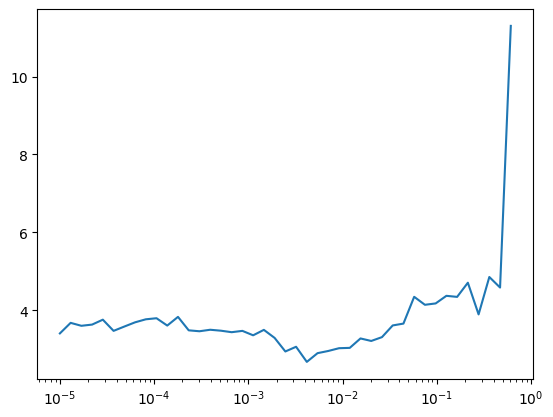

In [278]:
learn.lr_find(start_lr=1e-5)

{'accuracy': '0.070', 'loss': '3.559', 'train': 'train', 'epoch': 0}
{'accuracy': '0.142', 'loss': '2.819', 'train': 'valid', 'epoch': 0}


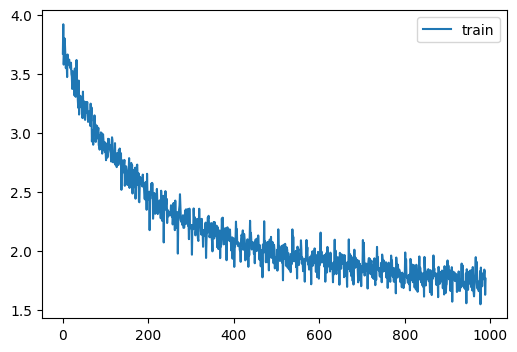

{'accuracy': '0.099', 'loss': '3.224', 'train': 'train', 'epoch': 1}
{'accuracy': '0.162', 'loss': '2.615', 'train': 'valid', 'epoch': 1}
{'accuracy': '0.124', 'loss': '2.976', 'train': 'train', 'epoch': 2}
{'accuracy': '0.189', 'loss': '2.551', 'train': 'valid', 'epoch': 2}
{'accuracy': '0.144', 'loss': '2.824', 'train': 'train', 'epoch': 3}
{'accuracy': '0.194', 'loss': '2.494', 'train': 'valid', 'epoch': 3}
{'accuracy': '0.165', 'loss': '2.685', 'train': 'train', 'epoch': 4}
{'accuracy': '0.215', 'loss': '2.457', 'train': 'valid', 'epoch': 4}
{'accuracy': '0.188', 'loss': '2.565', 'train': 'train', 'epoch': 5}
{'accuracy': '0.237', 'loss': '2.398', 'train': 'valid', 'epoch': 5}
{'accuracy': '0.226', 'loss': '2.420', 'train': 'train', 'epoch': 6}
{'accuracy': '0.240', 'loss': '2.405', 'train': 'valid', 'epoch': 6}
{'accuracy': '0.249', 'loss': '2.331', 'train': 'train', 'epoch': 7}
{'accuracy': '0.268', 'loss': '2.265', 'train': 'valid', 'epoch': 7}
{'accuracy': '0.257', 'loss': '2.2

In [381]:
learn.fit(30,cbs=all_cbs,lr=1e-4)

- ooo wee look at me I've successfully attached the activations callback to monitor the inner activations of the model.
Now let's take a look at them.

In [376]:
acts_hook.hooks = [hook for hook in acts_hook.hooks if hasattr(hook, 'stats')]

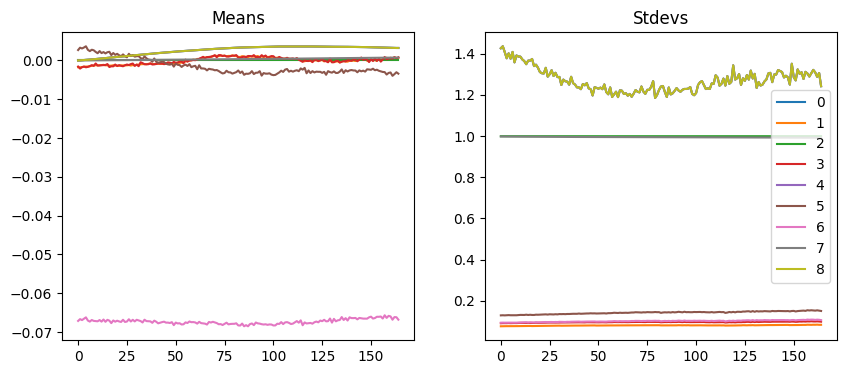

In [377]:

acts_hook.plot_stats()

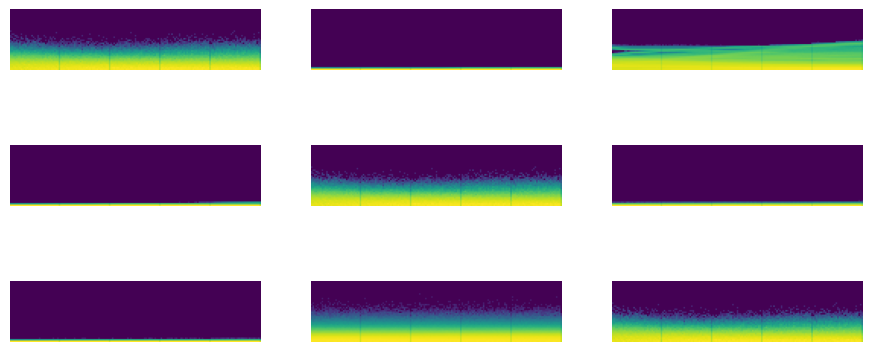

In [378]:
acts_hook.color_dim()

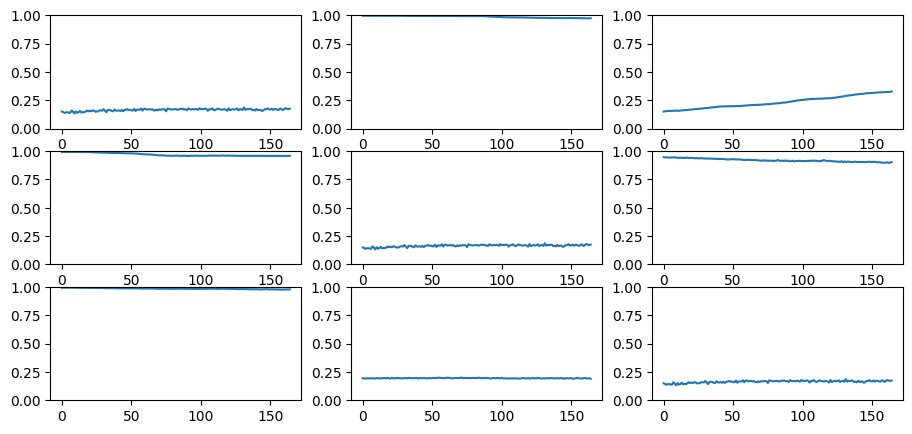

In [379]:
acts_hook.dead_chart()

# Training

In [333]:
ds_train = CMIData(train, max_length=MAX_LENGTH)
train_loader = DataLoader(
    ds_train, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn, 
    drop_last=True
)
print(f"Training dataset contains: {len(ds_train)}")
ds_valid = CMIData(valid, max_length=MAX_LENGTH)
valid_loader = DataLoader(
    ds_valid,
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    drop_last=True,
)
print(f"Valid dataset contains: {len(ds_valid)}")

Training dataset contains: 6520
Valid dataset contains: 1631


In [ ]:
model = LSTMClassifier().to(DEVICE)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=10, min_lr=LR_MIN
)

c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


: 

: 

: 

In [309]:
def evalute(model, data_loader, loss_fn):
    model.eval()
    loss = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss += loss_fn(logits, y).item()
    model.train()
    return loss / len(data_loader)

In [334]:
def predict(model, data):
    model.eval()
    ds = CMIData(data, max_length=55)
    dl = DataLoader(
        ds, shuffle=False, batch_size=BATCH_SIZE, collate_fn=collate_fn, drop_last=False
    )
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            y_pred.append(torch.argmax(logits, dim=-1).cpu().numpy())
            y_true.append(y.cpu().numpy())
    sol = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_true)].values}
    )
    sub = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_pred)].values}
    )
    return sol, sub

In [335]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.6368024788845782

In [313]:
joblib.dump(transformer, OUT_DIR / "second_lstm_preprocessing.joblib")

['second_lstm_preprocessing.joblib']

In [315]:
torch.save(model.state_dict(),"lstm_third_attempt.pth")

In [320]:
torch.save(encoder_with_pooling.state_dict(),"autoencoder_second.pth")

In [316]:
model = LSTMClassifier()

c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [318]:
model.load_state_dict(torch.load("lstm_third_attempt.pth",weights_only=True))

c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [ ]:
class Monitor:
    def __init__(self):
        self.records = collections.defaultdict(list)

    def add(self, metric_name, epoch, value):
        self.records[metric_name].append({"epoch": epoch, "value": value})
        print(f"Epoch {epoch}/{EPOCHS} - {metric_name}: {value:.4g}")

    @property
    def dataframe(self):
        return pd.DataFrame(
            {
                k: pd.DataFrame(v).rename(columns={"value": k}).set_index("epoch")[k]
                for k, v in self.records.items()
            }
        )

: 

: 

: 

In [ ]:
%%time

best_val_loss = float('inf')
best_val_score = float('-inf')

# training loop
monitor = Monitor()
for epoch in tqdm(range(1, EPOCHS + 1)):
    
    # training
    model.train()
    losses = []
    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    monitor.add("train_loss", epoch, train_loss)
    
    # validation
    val_loss = evalute(model, valid_loader, loss_fn)
    monitor.add("val_loss", epoch, val_loss)
    sol, sub = predict(model, valid)
    val_score = cmi_score(sol, sub, "id")
    monitor.add("val_cmi", epoch, val_score)
    scheduler.step(val_loss)
    monitor.add("lr", epoch, optimizer.param_groups[0]['lr'])

    # checkpointing
    if val_loss < best_val_loss:
        print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4}")
        path_model = OUT_DIR / "model_best.pt"
        torch.save(model.state_dict(), path_model)
        best_val_loss = val_loss

    # checkpointing
    if val_score > best_val_score:
        print(f"Validation score improved from {best_val_score:.4f} to {val_score:.4}")
        path_model_score = OUT_DIR / "model_best_score.pt"
        torch.save(model.state_dict(), path_model_score)
        best_val_score = val_score

  0%|          | 0/70 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 2.608
Epoch 1/70 - val_loss: 2.552
Epoch 1/70 - val_cmi: 0.4236
Epoch 1/70 - lr: 0.001
Validation loss improved from inf to 2.552
Validation score improved from -inf to 0.4236
Epoch 2/70 - train_loss: 2.537
Epoch 2/70 - val_loss: 2.529
Epoch 2/70 - val_cmi: 0.3676
Epoch 2/70 - lr: 0.001
Validation loss improved from 2.5515 to 2.529
Epoch 3/70 - train_loss: 2.494
Epoch 3/70 - val_loss: 2.461
Epoch 3/70 - val_cmi: 0.4849
Epoch 3/70 - lr: 0.001
Validation loss improved from 2.5294 to 2.461
Validation score improved from 0.4236 to 0.4849
Epoch 4/70 - train_loss: 2.412
Epoch 4/70 - val_loss: 2.33
Epoch 4/70 - val_cmi: 0.4792
Epoch 4/70 - lr: 0.001
Validation loss improved from 2.4614 to 2.33
Epoch 5/70 - train_loss: 2.313
Epoch 5/70 - val_loss: 2.229
Epoch 5/70 - val_cmi: 0.5357
Epoch 5/70 - lr: 0.001
Validation loss improved from 2.3298 to 2.229
Validation score improved from 0.4849 to 0.5357
Epoch 6/70 - train_loss: 2.284
Epoch 6/70 - val_loss: 2.269
Epoch 6/70 - 

KeyboardInterrupt: 

: 

: 

: 

: 

: 

: 

In [ ]:
hist.loc[hist["val_loss"].idxmin()]

train_loss    1.415868
val_loss      1.797070
val_cmi       0.671300
lr            0.001000
Name: 27, dtype: float64

: 

: 

: 

In [ ]:
hist.loc[hist["val_cmi"].idxmax()]

train_loss    1.504180
val_loss      1.838646
val_cmi       0.677327
lr            0.001000
Name: 25, dtype: float64

: 

: 

: 

NameError: name 'hist' is not defined

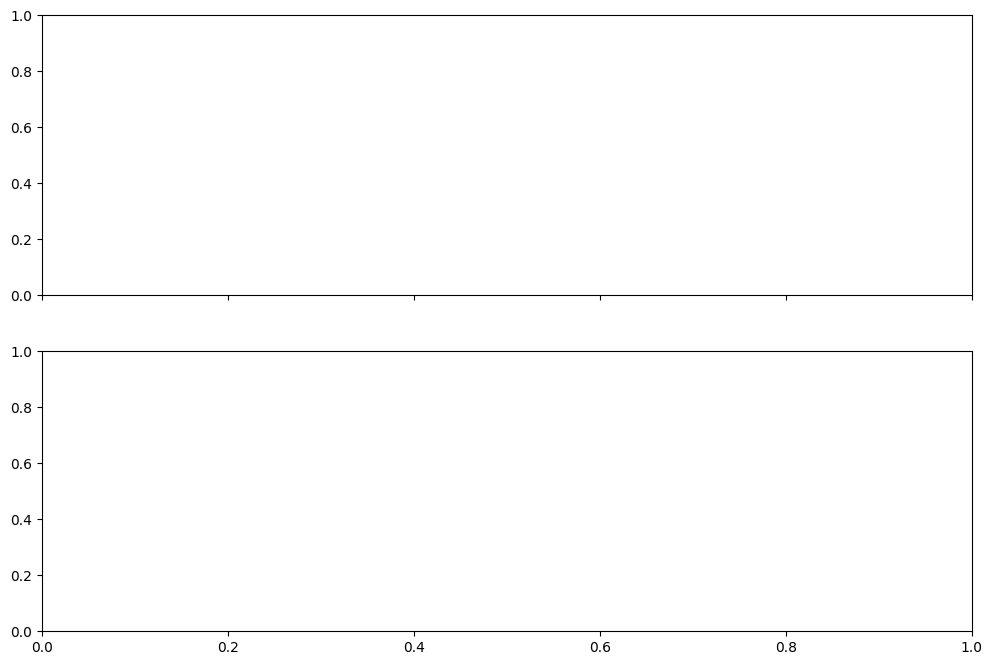

: 

: 

: 

In [ ]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), sharex="col")
plt_kwargs = dict(grid=True, marker='x')
hist[["train_loss", "val_loss"]].plot(ax=axs[0], **plt_kwargs)
hist[["val_cmi"]].plot(ax=axs[1], **plt_kwargs)
plt.show()

# Eval

In [ ]:
torch.save(model.state_dict(), OUT_DIR / "lstm_weights_first.pth")

: 

: 

: 

In [ ]:
model.load_state_dict(torch.load(path_model, weights_only=True))

<All keys matched successfully>

: 

: 

: 

In [ ]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

NameError: name 'predict' is not defined

: 

: 

: 

In [ ]:
model.load_state_dict(torch.load(path_model_score, weights_only=True))

<All keys matched successfully>

: 

: 

: 

In [ ]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.3944116347311109

: 

: 

: 